In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, special
import math as mt
plt.style.use("ggplot")
np.random.seed(44)

n = 139
m = 1000
alpha = 0.05

sgm_evr_ln = 6.161
sgm_evr_wt = 5.055
sgm_eg_ln = 5.722
sgm_eg_wt = 4.612

In [29]:
F_alpha_2 = stats.f.ppf(alpha / 2, 138, 999)
F_1alpha = stats.f.ppf(1 - alpha / 2, 138, 999)
print(F_alpha_2)
print(F_1alpha)

0.7673823155977318
1.271697073036989


In [31]:
delta_ln = (sgm_eg_ln / sgm_evr_ln) ** 2
p_value = stats.f.sf(delta_ln, n-1, m-1)

print(f"Дельта с волной для длины = {np.round(delta_ln, 5)}, критическая область G: delta >= {np.round(F_1alpha, 5)}")
print("Нет веских оснований отвергнуть H0" if F_alpha_2 < delta_ln < F_1alpha else "Отвергаем H0")

print("Проверка по p-value:")
print(f"p-value = {np.round(p_value, 4)}")
print("Нет веских оснований отвергнуть H0\n" if p_value > alpha else "Отвергаем H0\n")

delta_wt = (sgm_eg_wt / sgm_evr_wt) ** 2
p_value = stats.f.sf(delta_wt, n-1, m-1)

print(f"Дельта с волной для ширины = {np.round(delta_wt, 5)}, критическая область G: delta >= {np.round(F_1alpha, 5)}")
print("Нет веских оснований отвергнуть H0" if F_alpha_2 < delta_wt < F_1alpha else "Отвергаем H0")

print("Проверка по p-value:")
print(f"p-value = {np.round(p_value, 4)}")
print("Нет веских оснований отвергнуть H0" if p_value > alpha else "Отвергаем H0")

Дельта с волной для длины = 0.86257, критическая область G: delta >= 1.2717
Нет веских оснований отвергнуть H0
Проверка по p-value:
p-value = 0.8636
Нет веских оснований отвергнуть H0

Дельта с волной для ширины = 0.83241, критическая область G: delta >= 1.2717
Нет веских оснований отвергнуть H0
Проверка по p-value:
p-value = 0.9134
Нет веских оснований отвергнуть H0


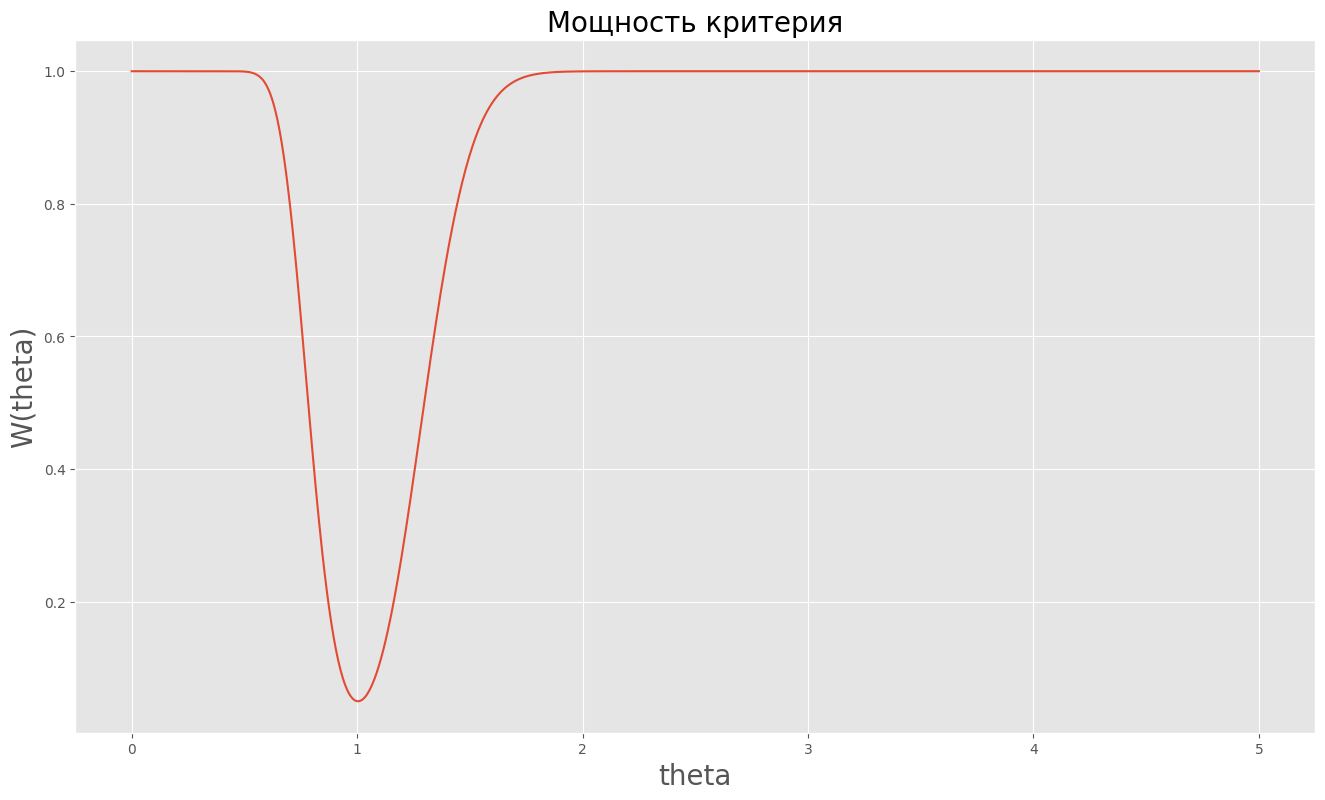

In [22]:
figure, axis = plt.subplots(figsize=(16,9))
x = np.linspace(0, 5, 1000)

y = stats.f.sf(F_1alpha * x, 138, 999) + stats.f.cdf(F_alpha_2 * x, 138, 999)

axis.plot(x, y)
axis.set_xlabel("theta", fontsize=20)
axis.set_ylabel("W(theta)", fontsize=20)
axis.set_title("Мощность критерия", fontsize=20)
plt.show()